# **Check data and modeling**

In [ ]:
import pandas as pd

df = pd.read_csv('/content/telco_ml_features.csv')

print(df.shape)
print(df.head())

(7043, 15)
   customerid  gender  seniorcitizen partner dependents  tenure  \
0  7590-VHVEG  Female              0     Yes         No       1   
1  5575-GNVDE    Male              0      No         No      34   
2  3668-QPYBK    Male              0      No         No       2   
3  7795-CFOCW    Male              0      No         No      45   
4  9237-HQITU  Female              0      No         No       2   

  internetservice        contract              paymentmethod  monthlycharges  \
0             DSL  Month-to-month           Electronic check           29.85   
1             DSL        One year               Mailed check           56.95   
2             DSL  Month-to-month               Mailed check           53.85   
3             DSL        One year  Bank transfer (automatic)           42.30   
4     Fiber optic  Month-to-month           Electronic check           70.70   

   totalcharges  is_churned  tenure_group charge_bucket  baseline_risk_score  
0         29.85           

#Check data

In [ ]:
df.dtypes

,0
customerid,object
gender,object
seniorcitizen,int64
partner,object
dependents,object
tenure,int64
internetservice,object
contract,object
paymentmethod,object
monthlycharges,float64


In [ ]:
df.isnull().sum()

,0
customerid,0
gender,0
seniorcitizen,0
partner,0
dependents,0
tenure,0
internetservice,0
contract,0
paymentmethod,0
monthlycharges,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,internetservice,contract,paymentmethod,monthlycharges,totalcharges,is_churned,tenure_group,charge_bucket,baseline_risk_score
0,7590-VHVEG,Female,0,Yes,No,1,DSL,Month-to-month,Electronic check,29.85,29.85,0,0_12_months,Low,3
1,5575-GNVDE,Male,0,No,No,34,DSL,One year,Mailed check,56.95,1889.50,0,25_48_months,Medium,1
2,3668-QPYBK,Male,0,No,No,2,DSL,Month-to-month,Mailed check,53.85,108.15,1,0_12_months,Medium,3
3,7795-CFOCW,Male,0,No,No,45,DSL,One year,Bank transfer (automatic),42.30,1840.75,0,25_48_months,Low,1
4,9237-HQITU,Female,0,No,No,2,Fiber optic,Month-to-month,Electronic check,70.70,151.65,1,0_12_months,Medium,5


In [ ]:
df_monthly_churned=df[df['is_churned'] == 1]

In [ ]:
df_monthly_churned.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,internetservice,contract,paymentmethod,monthlycharges,totalcharges,is_churned,tenure_group,charge_bucket,baseline_risk_score
2,3668-QPYBK,Male,0,No,No,2,DSL,Month-to-month,Mailed check,53.85,108.15,1,0_12_months,Medium,3
4,9237-HQITU,Female,0,No,No,2,Fiber optic,Month-to-month,Electronic check,70.70,151.65,1,0_12_months,Medium,5
5,9305-CDSKC,Female,0,No,No,8,Fiber optic,Month-to-month,Electronic check,99.65,820.50,1,0_12_months,High,5
8,7892-POOKP,Female,0,Yes,No,28,Fiber optic,Month-to-month,Electronic check,104.80,3046.05,1,25_48_months,High,4
13,0280-XJGEX,Male,0,No,No,49,Fiber optic,Month-to-month,Bank transfer (automatic),103.70,5036.30,1,over_48_months,High,4


In [ ]:
df_monthly_churned.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges,is_churned,baseline_risk_score
count,1869.000000,1869.000000,1869.000000,1869.000000,1869.0,1869.000000
mean,0.254682,17.979133,74.441332,1531.796094,1.0,3.638844
std,0.435799,19.531123,24.666053,1890.822994,0.0,1.200736
min,0.000000,1.000000,18.850000,18.850000,1.0,0.000000
25%,0.000000,2.000000,56.150000,134.500000,1.0,3.000000
50%,0.000000,10.000000,79.650000,703.550000,1.0,4.000000
75%,1.000000,29.000000,94.200000,2331.300000,1.0,5.000000
max,1.000000,72.000000,118.350000,8684.800000,1.0,5.000000


In [ ]:
df[df['totalcharges'].isnull()][
    ['tenure', 'monthlycharges', 'totalcharges', 'contract', 'is_churned']
]

,tenure,monthlycharges,totalcharges,contract,is_churned
488,0,52.55,NaN,Two year,0
756,0,20.25,NaN,Two year,0
939,0,80.85,NaN,Two year,0
1085,0,25.75,NaN,Two year,0
1343,0,56.05,NaN,Two year,0
3335,0,19.85,NaN,Two year,0
3830,0,25.35,NaN,Two year,0
4380,0,20.00,NaN,Two year,0
5218,0,19.70,NaN,One year,0
6670,0,73.35,NaN,Two year,0


In [ ]:
df['totalcharges']=df['totalcharges'].fillna(0)

In [ ]:
df[df['totalcharges'].isnull()]['tenure'].value_counts()

,count
tenure,


In [ ]:
df['is_churned'].value_counts(normalize=True)

,proportion
is_churned,
0,0.73463
1,0.26537


In [ ]:
df[['tenure', 'monthlycharges', 'totalcharges']].describe()

,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


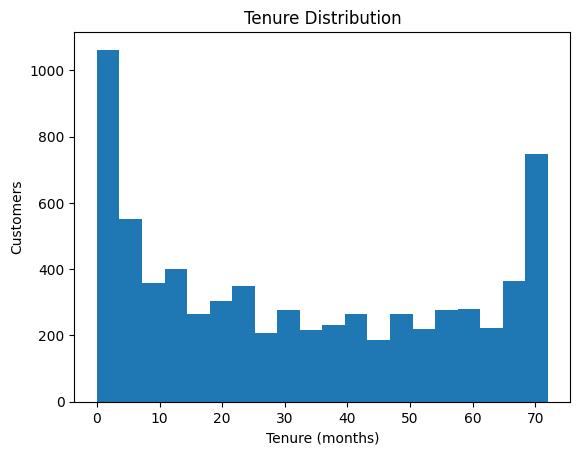

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['tenure'], bins=20)
plt.xlabel('Tenure (months)')
plt.ylabel('Customers')
plt.title('Tenure Distribution')
plt.show()

In [ ]:
df['tenure'].value_counts().sort_index().head(15)

,count
tenure,
0,11
1,613
2,238
3,200
4,176
5,133
6,110
7,131
8,123


In [ ]:
df.groupby('tenure')['is_churned'].mean().head(15)

,is_churned
tenure,
0,0.000000
1,0.619902
2,0.516807
3,0.470000
4,0.471591
5,0.481203
6,0.363636
7,0.389313
8,0.341463




---
**ลูกค้าที่มี tenure ต่ำ โดยเฉพาะช่วงเดือนแรก ๆ มี Churn Rate สูง และแนวโน้มโดยรวมลดลงเมื่อ tenure เพิ่มขึ้น**


In [ ]:
df.groupby('tenure_group')['is_churned'].mean()

,is_churned
tenure_group,
0_12_months,0.474382
13_24_months,0.287109
25_48_months,0.203890
over_48_months,0.095132


In [ ]:
df.groupby('charge_bucket')['is_churned'].mean()

,is_churned
charge_bucket,
High,0.339835
Low,0.157367
Medium,0.289006


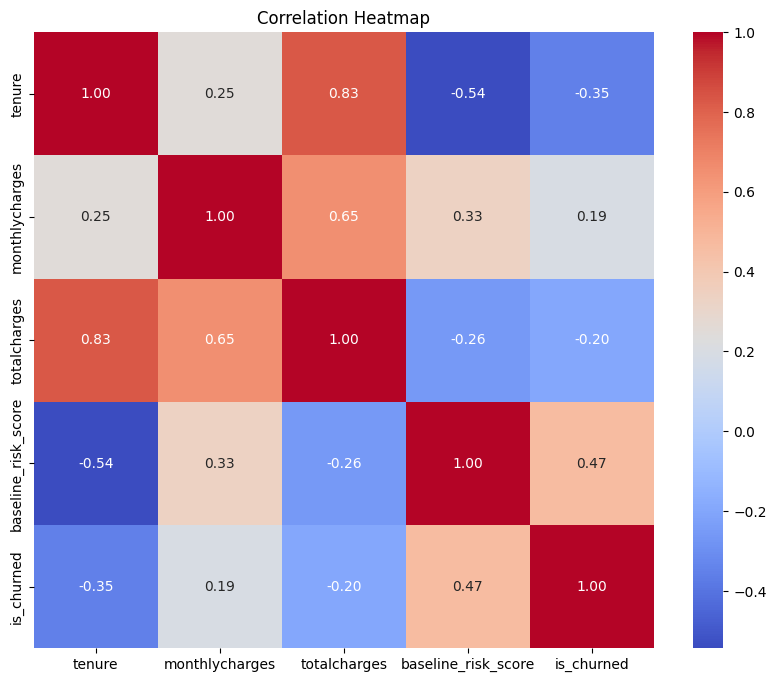

In [ ]:
import seaborn as sns

numeric_cols = ['tenure', 'monthlycharges', 'totalcharges', 'baseline_risk_score', 'is_churned']
df_numeric=df[numeric_cols]

corr_matrix = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# ทำ Encode และ drop (customerid','totalcharges)

In [ ]:
df_model = df[[
    'seniorcitizen', 'tenure', 'monthlycharges',
    'gender', 'partner', 'dependents',
    'internetservice', 'contract', 'paymentmethod',
    'is_churned'
]]

df_encode = pd.get_dummies(df_model, drop_first=True)
df_encoded = df_encode.astype(float)

print(f"จำนวน Features ทั้งหมดพร้อมเทรน: {df_encoded.shape[1]} คอลัมน์")
print(df_encoded.columns.tolist())
display(df_encoded.head())

จำนวน Features ทั้งหมดพร้อมเทรน: 14 คอลัมน์
['seniorcitizen', 'tenure', 'monthlycharges', 'is_churned', 'gender_Male', 'partner_Yes', 'dependents_Yes', 'internetservice_Fiber optic', 'internetservice_No', 'contract_One year', 'contract_Two year', 'paymentmethod_Credit card (automatic)', 'paymentmethod_Electronic check', 'paymentmethod_Mailed check']


,seniorcitizen,tenure,monthlycharges,is_churned,gender_Male,partner_Yes,dependents_Yes,internetservice_Fiber optic,internetservice_No,contract_One year,contract_Two year,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,0.0,1.0,29.85,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,34.0,56.95,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.0,2.0,53.85,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,45.0,42.30,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,2.0,70.70,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


basic

In [ ]:
colr_to_drop=['customerid','totalcharges','baseline_risk_score']
df_model=df.drop(columns=colr_to_drop)
df_encode=pd.get_dummies(df_model,drop_first=True)

df_encoded = df_encode.astype(float)
print(f"จำนวน Features ทั้งหมดพร้อมเทรน: {df_encoded.shape[1]} คอลัมน์")
print(df_encoded.columns.tolist())
display(df_encoded.head())

จำนวน Features ทั้งหมดพร้อมเทรน: 19 คอลัมน์
['seniorcitizen', 'tenure', 'monthlycharges', 'is_churned', 'gender_Male', 'partner_Yes', 'dependents_Yes', 'internetservice_Fiber optic', 'internetservice_No', 'contract_One year', 'contract_Two year', 'paymentmethod_Credit card (automatic)', 'paymentmethod_Electronic check', 'paymentmethod_Mailed check', 'tenure_group_13_24_months', 'tenure_group_25_48_months', 'tenure_group_over_48_months', 'charge_bucket_Low', 'charge_bucket_Medium']


,seniorcitizen,tenure,monthlycharges,is_churned,gender_Male,partner_Yes,dependents_Yes,internetservice_Fiber optic,internetservice_No,contract_One year,contract_Two year,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check,tenure_group_13_24_months,tenure_group_25_48_months,tenure_group_over_48_months,charge_bucket_Low,charge_bucket_Medium
0,0.0,1.0,29.85,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,34.0,56.95,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,0.0,2.0,53.85,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,45.0,42.30,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.0,2.0,70.70,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


use features 13

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

X = df_encoded.drop(columns=['is_churned'])
y = df_encoded['is_churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print(f"ขนาดของ Train Set สำหรับสอนโมเดล: {X_train_scaled.shape}")
print(f"ขนาดของ Test Set สำหรับทดสอบโมเดล: {X_test_scaled.shape}")

ขนาดของ Train Set สำหรับสอนโมเดล: (5634, 13)
ขนาดของ Test Set สำหรับทดสอบโมเดล: (1409, 13)


กำลังค้นหา Hyperparameter ที่ดีที่สุดด้วย RandomizedSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 8, 'class_weight': 'balanced_subsample'}
Best CV F1: 0.6393

Top 5 Models by F1 Score:
    mean_test_recall  mean_test_precision  mean_test_f1  mean_test_roc_auc  \
5              0.780                0.542         0.639              0.841   
12             0.783                0.539         0.638              0.842   
8              0.750                0.553         0.636              0.840   
3              0.784                0.534         0.635              0.842   
21             0.796                0.528         0.635              0.843   

    mean_test_avg_precision  
5                     0.644  
12                    0.645  
8                     0.642  
3                     0.639  
21                    0.643  

--- ค้นหา Optima

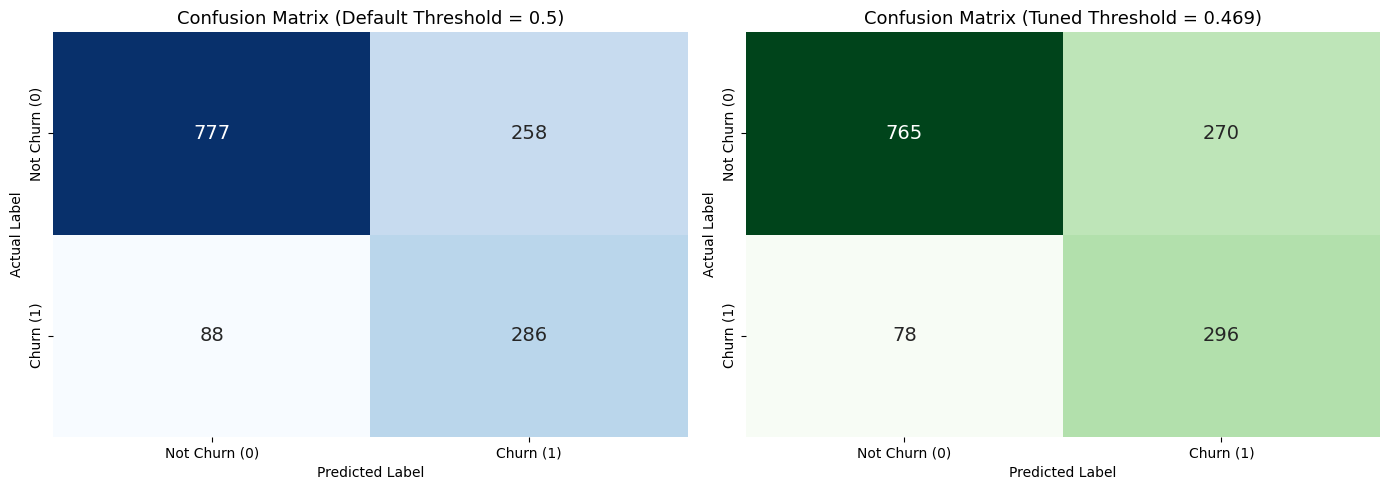

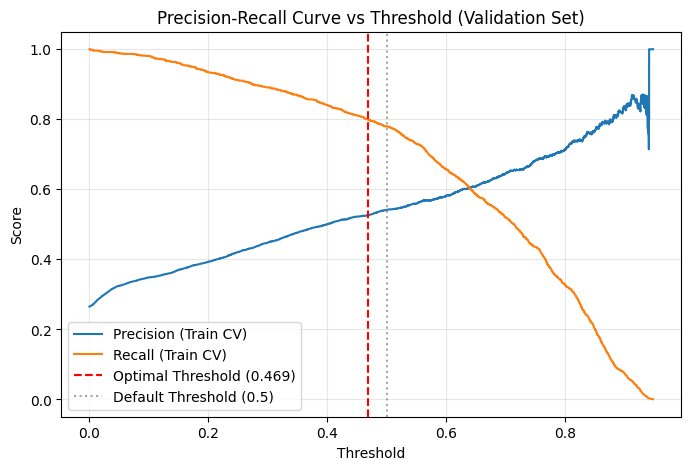


กำลังคำนวณ Permutation Importance...


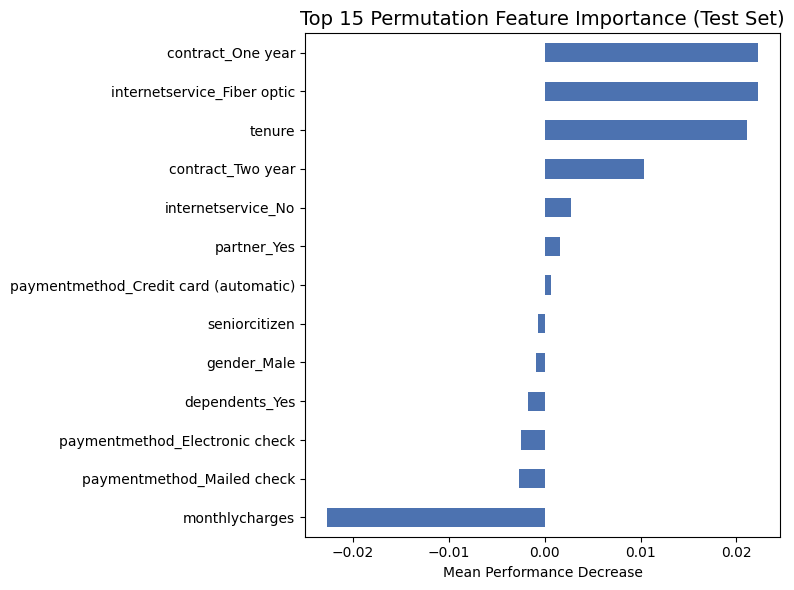

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
)
from sklearn.inspection import permutation_importance

# ---------------------------------------------------------
# 1. กำหนด Hyperparameter Search Space
# ---------------------------------------------------------
# หมายเหตุ: ไม่จำเป็นต้องใช้ X_train_scaled กับ Random Forest สามารถใช้ X_train ได้เลย
param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [8, 12, 16, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.5],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_model = RandomForestClassifier(random_state=42)

scoring = {
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'avg_precision': 'average_precision'
}

# เปลี่ยนจาก GridSearchCV เป็น RandomizedSearchCV เพื่อป้องกันปัญหาการค้าง/ใช้เวลานานเกินไป
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=30,                  # สุ่มลอง 30 รูปแบบ (ประมวลผลเร็วขึ้นมาก)
    cv=5,
    scoring=scoring,
    refit='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("กำลังค้นหา Hyperparameter ที่ดีที่สุดด้วย RandomizedSearchCV...")
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
print(f"\nBest Parameters: {random_search.best_params_}")
print(f"Best CV F1: {random_search.best_score_:.4f}")

# แสดง Top 5 โมเดลตามค่า F1
results_df = pd.DataFrame(random_search.cv_results_)
print("\nTop 5 Models by F1 Score:")
print(results_df.sort_values('rank_test_f1')
      .head(5)[['mean_test_recall', 'mean_test_precision', 'mean_test_f1',
                'mean_test_roc_auc', 'mean_test_avg_precision']]
      .round(3))


# ---------------------------------------------------------
# 2. หา Threshold บน Train Set ผ่าน Cross-Validation (ป้องก้น Data Leakage)
# ---------------------------------------------------------
print("\n--- ค้นหา Optimal Threshold จาก Train Set (Out-of-Fold) ---")
y_train_proba = cross_val_predict(best_model, X_train, y_train, cv=5, method='predict_proba')[:, 1]
precisions_tr, recalls_tr, thresholds_tr = precision_recall_curve(y_train, y_train_proba)

target_recall = 0.80
valid_idx = np.where(recalls_tr[:-1] >= target_recall)[0]

if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(precisions_tr[:-1][valid_idx])]
    best_threshold = thresholds_tr[best_idx]
    print(f"Threshold แนะนำ (Recall >= {target_recall}): {best_threshold:.3f}")
    print(f"-> Train Precision: {precisions_tr[best_idx]:.3f} | Train Recall: {recalls_tr[best_idx]:.3f}")
else:
    best_threshold = 0.5
    print(f"ไม่พบ threshold ที่ทำให้ recall >= {target_recall} จะใช้ค่า default 0.5")


# ---------------------------------------------------------
# 3. นำโมเดลและ Threshold ไปวัดผลบน Test Set จริง
# ---------------------------------------------------------
print("\n--- ประเมินผลโมเดลบน Test Set ---")
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# ทำความสะอาดการทำนายทั้ง 2 แบบ (Default vs Tuned Threshold)
y_pred_default = best_model.predict(X_test)
y_pred_tuned = (y_proba_test >= best_threshold).astype(int)

print("\n[1] Classification Report (Default Threshold = 0.5):")
print(classification_report(y_test, y_pred_default))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_test):.4f}")

print(f"\n[2] Classification Report (Tuned Threshold = {best_threshold:.3f}):")
print(classification_report(y_test, y_pred_tuned))


# ---------------------------------------------------------
# 4. วาด Confusion Matrix เปรียบเทียบ 2 Thresholds
# ---------------------------------------------------------
cm_default = confusion_matrix(y_test, y_pred_default)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn (0)', 'Churn (1)'],
            yticklabels=['Not Churn (0)', 'Churn (1)'],
            cbar=False, annot_kws={"size": 14}, ax=axes[0])
axes[0].set_title('Confusion Matrix (Default Threshold = 0.5)', fontsize=13)
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Churn (0)', 'Churn (1)'],
            yticklabels=['Not Churn (0)', 'Churn (1)'],
            cbar=False, annot_kws={"size": 14}, ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Tuned Threshold = {best_threshold:.3f})', fontsize=13)
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 5. วาด Precision-Recall vs Threshold Curve (จาก Train Set)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(thresholds_tr, precisions_tr[:-1], label='Precision (Train CV)')
plt.plot(thresholds_tr, recalls_tr[:-1], label='Recall (Train CV)')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Optimal Threshold ({best_threshold:.3f})')
plt.axvline(x=0.5, color='gray', linestyle=':', alpha=0.7, label='Default Threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Curve vs Threshold (Validation Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ---------------------------------------------------------
# 6. Permutation Feature Importance บน Test Set
# ---------------------------------------------------------
print("\nกำลังคำนวณ Permutation Importance...")
perm_result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"Feature {i}" for i in range(X_train.shape[1])]
importances_perm = pd.Series(perm_result.importances_mean, index=feature_names)
importances_perm = importances_perm.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances_perm.plot(kind='barh', color='#4C72B0')
plt.gca().invert_yaxis()
plt.title('Top 15 Permutation Feature Importance (Test Set)', fontsize=14)
plt.xlabel('Mean Performance Decrease')
plt.tight_layout()
plt.show()

#ลอง model ตัวอื่น

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
import pandas as pd

# LR ใส่ scaler ในตัวเอง (LR ไวต่อ scale) ส่วน tree-based ไม่ต้อง scale
models = {
    'Logistic Regression': Pipeline([
        ('scaler', MinMaxScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced_subsample', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

# ตัวไหน import ไม่ได้ (ยังไม่ได้ลง) จะข้ามไปเฉยๆ ไม่พัง
try:
    from xgboost import XGBClassifier
    spw = (y_train == 0).sum() / (y_train == 1).sum()
    models['XGBoost'] = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42)
except ImportError:
    print("XGBoost ยังไม่ได้ติดตั้ง -> pip install xgboost ถ้าอยากลอง")

try:
    from lightgbm import LGBMClassifier
    models['LightGBM'] = LGBMClassifier(class_weight='balanced', random_state=42, verbosity=-1)
except ImportError:
    print("LightGBM ยังไม่ได้ติดตั้ง -> pip install lightgbm ถ้าอยากลอง")

scoring = {'recall': 'recall', 'precision': 'precision', 'f1': 'f1',
           'roc_auc': 'roc_auc', 'avg_precision': 'average_precision'}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results.append({
        'Model': name,
        'Recall': scores['test_recall'].mean(),
        'Precision': scores['test_precision'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean(),
        'PR-AUC': scores['test_avg_precision'].mean(),
    })

comparison_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print(comparison_df.round(3).to_string(index=False))

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


              Model  Recall  Precision    F1  ROC-AUC  PR-AUC
           LightGBM   0.761      0.538 0.630    0.834   0.634
Logistic Regression   0.806      0.506 0.621    0.837   0.626
            XGBoost   0.695      0.538 0.607    0.817   0.602
  Gradient Boosting   0.502      0.645 0.564    0.841   0.646
      Random Forest   0.480      0.602 0.533    0.804   0.573


ค้ด model และทำการบันทึกผล

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier

param_dist_lgbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, -1],          # -1 = ไม่จำกัดความลึก
    'num_leaves': [15, 31, 63],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(class_weight='balanced', random_state=42, verbosity=-1),
    param_distributions=param_dist_lgbm,
    n_iter=20, cv=5, scoring='f1', n_jobs=-1, random_state=42
)

lgbm_search.fit(X_train, y_train)
print(f"Best F1: {lgbm_search.best_score_:.4f}")
print(f"Best Params: {lgbm_search.best_params_}")

Best F1: 0.6319
Best Params: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 5, 'learning_rate': 0.01}


In [ ]:
import joblib

# best_model = RF ที่ tune แล้วจาก RandomizedSearchCV (cell 24)
joblib.dump(best_model, 'churn_model.pkl')

# เก็บชื่อ columns ตามลำดับที่ train ไว้ (สำคัญมาก ต้องตรงเป๊ะตอน predict)
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')

# เก็บ threshold ที่ tune ไว้ด้วย (0.469)
joblib.dump(best_threshold, 'threshold.pkl')

# โหลดไฟล์ทั้ง 3 ลงเครื่อง
from google.colab import files
files.download('churn_model.pkl')
files.download('feature_columns.pkl')
files.download('threshold.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

model = joblib.load("churn_model.pkl")
feature_columns = joblib.load("feature_columns.pkl")

print(model)
print(feature_columns)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=8,
                       max_features=0.5, min_samples_split=5, n_estimators=300,
                       random_state=42)
['seniorcitizen', 'tenure', 'monthlycharges', 'gender_Male', 'partner_Yes', 'dependents_Yes', 'internetservice_Fiber optic', 'internetservice_No', 'contract_One year', 'contract_Two year', 'paymentmethod_Credit card (automatic)', 'paymentmethod_Electronic check', 'paymentmethod_Mailed check']


# **Business-Centric-Approach**

# **ค่าต่างๆของลูกค้าที่ยกเลิกใช้บริการไปแล้ว**

In [ ]:
df_monthly_churned.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges,is_churned,baseline_risk_score
count,1869.000000,1869.000000,1869.000000,1869.000000,1869.0,1869.000000
mean,0.254682,17.979133,74.441332,1531.796094,1.0,3.638844
std,0.435799,19.531123,24.666053,1890.822994,0.0,1.200736
min,0.000000,1.000000,18.850000,18.850000,1.0,0.000000
25%,0.000000,2.000000,56.150000,134.500000,1.0,3.000000
50%,0.000000,10.000000,79.650000,703.550000,1.0,4.000000
75%,1.000000,29.000000,94.200000,2331.300000,1.0,5.000000
max,1.000000,72.000000,118.350000,8684.800000,1.0,5.000000


**จากกลุ่มลูกค้าที่ Churn พบว่า MonthlyCharges มีค่าเฉลี่ยประมาณ 74.44 /mothly ซึ่งสะท้อนว่าลูกค้าที่สูญเสียไปแต่ละรายมีรายได้ประจำที่บริษัทอาจสูญเสียในอนาคต**

---



**ดังนั้น Model นี้ไม่ได้มีเป้าหมายเพียงเพื่อทำนายว่าใครจะ Churn แต่สามารถนำผลการทำนายมาใช้เพื่อ ระบุลูกค้าที่มีความเสี่ยงสูงและประเมิน Monthly Revenue at Risk เพื่อช่วยจัดลำดับความสำคัญของ Retention Campaign or Promotion**

###  RandomizedSearchCV / Tuning Results

**Best CV F1:** `0.6393`

**Best Parameters:**
* `n_estimators`: 300
* `min_samples_split`: 5
* `min_samples_leaf`: 1
* `max_features`: 0.5
* `max_depth`: 8
* `class_weight`: 'balanced_subsample'

---

**Top 5 Models by F1 Score:**

| Model Index | Mean Test Recall | Mean Test Precision | Mean Test F1 | Mean Test ROC AUC | Mean Test Avg Precision |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **5** | 0.780 | 0.542 | 0.639 | 0.841 | 0.644 |
| **12** | 0.783 | 0.539 | 0.638 | 0.842 | 0.645 |
| **8** | 0.750 | 0.553 | 0.636 | 0.840 | 0.642 |
| **3** | 0.784 | 0.534 | 0.635 | 0.842 | 0.639 |
| **21** | 0.796 | 0.528 | 0.635 | 0.843 | 0.643 |

# **ค่าจากmodel บอกอะไรเราได้บ้าง สามารถบอกอะไรได้บ้าง**

---



Model สามารถแยกกลุ่มลูกค้าที่มีแนวโน้ม Churn และ Non-Churn ได้ค่อนข้างดี โดยมี ROC-AUC ประมาณ 0.84 ซึ่งหมายความว่าโมเดลมีความสามารถในการจัดอันดับความเสี่ยงของลูกค้าได้ดี

เมื่อพิจารณาในมุมของการตรวจจับลูกค้าที่กำลังจะ Churn โมเดลมี Recall ประมาณ 79% ซึ่งหมายความว่าสามารถตรวจจับลูกค้าที่ Churn จริงได้ประมาณ 79% ของทั้งหมด

อย่างไรก็ตาม Precision อยู่ที่ประมาณ 52% เท่านั้น หมายความว่าในกลุ่มลูกค้าที่โมเดลระบุว่าเป็นกลุ่มเสี่ยง จะมีเพียงประมาณครึ่งหนึ่งที่ Churn จริง ส่วนที่เหลือเป็น False Positive

ดังนั้นโมเดลนี้มีแนวโน้มเหมาะกับการใช้เป็นเครื่องมือสำหรับคัดกรองลูกค้าที่มีความเสี่ยง มากกว่าการตัดสินว่าลูกค้ารายใดจะ Churn อย่างแน่นอน

# **resoult test**

**Classification Report (Tuned Threshold = 0.469)**

| Class / Metric | Precision | Recall | F1-Score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **0.0** | 0.91 | 0.74 | 0.81 | 1035 |
| **1.0** | 0.52 | 0.79 | 0.63 | 374 |
| **accuracy** | | | **0.75** | 1409 |
| **macro avg** | 0.72 | 0.77 | 0.72 | 1409 |
| **weighted avg** | 0.81 | 0.75 | 0.77 | 1409 |

In [ ]:
y_test.shape

(1409,)

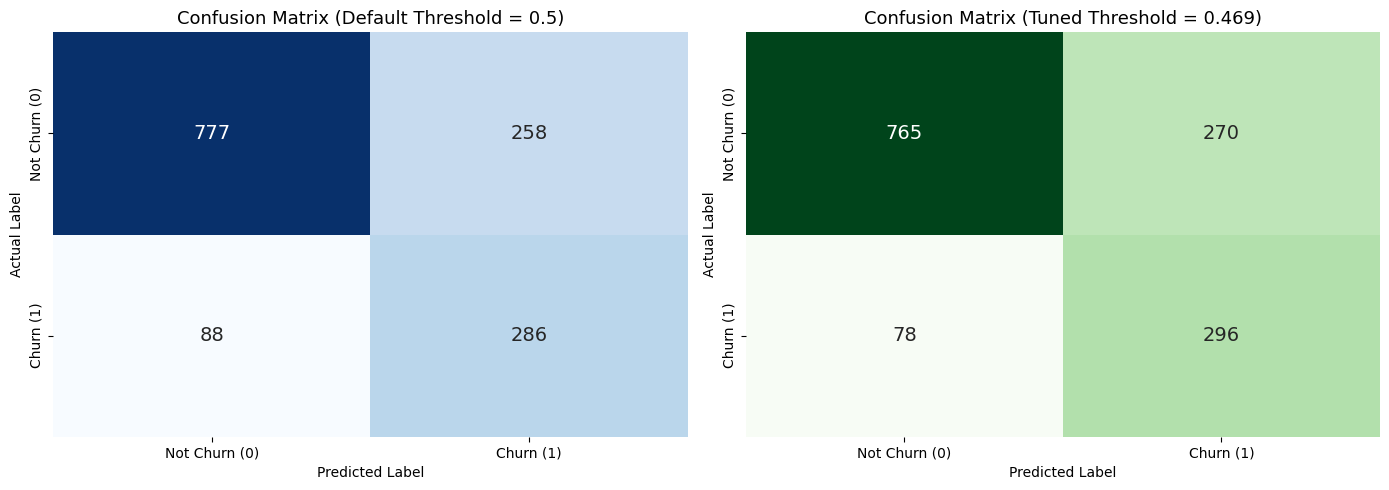

**1**.กลุ่มลูกค้าที่จะยกเลิกบริการจริง (Support ของคลาส 1.0) = 374 คนRecall (0.79): โมเดลจับลูกค้าที่จะยกเลิกจริงได้กี่คน
?True Positives (TP): $374 \times 0.79 \approx 295$  คนPrecision (0.52): จากคนที่โมเดลทายว่าจะยกเลิกทั้งหมด เป็นคนที่ยกเลิกจริงแค่ 52% แปลว่าเรามีการทายผิด (ทายว่าออก แต่จริงๆ ไม่ออก) รวมอยู่ด้วยจำนวนลูกค้าที่โมเดลชี้เป้าทั้งหมด: $295 \div 0.52 \approx 567$ คนFalse Positives (FP): $567 - 295 = 272$ คน (กลุ่มนี้คือคนที่ "ไม่ได้จะยกเลิก" แต่โมเดลทายผิด บริษัทจึงเสียต้นทุนแจกโปรโมชั่นไปฟรีๆ)

**2.** คำนวณความคุ้มค่าจากการทำ Promotion เฉลี่ยรายเดือนต่อตัวลูกค้าที่ยกเลิก  74.441332 ถ้าต้องการจัด promotion ลดราคา 20% ต้องเสียเท่าไหร่ต่อหัว
74.441332 * 0.20  = 15 หน่วยต่อหัว
 อัตราความสำเร็จ (Success Rate): เมื่อเสนอส่วนลดไปแล้ว ไม่ใช่ทุกคนจะอยู่ต่อ สมมติว่าดึงลูกค้ากลับมาได้ 50%

 **3.** คำนวณ Business Impact (ความคุ้มค่าทางธุรกิจ)

** ต้นทุนในการทำแคมเปญ (Cost)**
* จำนวนคนที่โมเดลทำนายว่าจะ Churn: `567` คน
* ต้นทุนโปรโมชั่น: `15` ต่อคน
* **รวมต้นทุน:** `567 * 15` = **`8,505` / เดือน**

**รายได้ที่กู้คืนมาได้ (Recovered Revenue)**
* คำนวณจาก: `(295 * 0.50) * 74.441`
* **รวมรายได้ที่รักษาไว้ได้:** **`10,980.05` / เดือน**

---

** กำไรสุทธิจากการใช้โมเดล (Net Profit)**

> **กำไรรายเดือน (Monthly):**
> 10,980.05 - 8,505 = **`2,475`**
>
> **กำไรรายปี (Yearly):**
> 2,475 * 12 = **`29,700`**



---


**แม้จะมี False Positive อยู่พอสมควร แต่การที่โมเดลมี Recall สูงทำให้สามารถนำไปใช้เพื่อคัดกรองลูกค้าที่มีความเสี่ยงจำนวนมาก และนำลูกค้ากลุ่มดังกล่าวไปจัดลำดับความสำคัญสำหรับ**